In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
df = pd.read_csv(r"C:\Users\sravy\OneDrive\Desktop\house_price_prediction\data (1).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 4600
Number of columns: 18

Column names:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,4600,70,2014-06-23 00:00:00,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,4600.0,NaN,NaN,NaN,551962.988473,563834.702547,0.0,322875.0,460943.461539,654962.5,26590000.0
bedrooms,4600.0,NaN,NaN,NaN,3.40087,0.908848,0.0,3.0,3.0,4.0,9.0
bathrooms,4600.0,NaN,NaN,NaN,2.160815,0.783781,0.0,1.75,2.25,2.5,8.0
sqft_living,4600.0,NaN,NaN,NaN,2139.346957,963.206916,370.0,1460.0,1980.0,2620.0,13540.0
sqft_lot,4600.0,NaN,NaN,NaN,14852.516087,35884.436145,638.0,5000.75,7683.0,11001.25,1074218.0
floors,4600.0,NaN,NaN,NaN,1.512065,0.538288,1.0,1.0,1.5,2.0,3.5
waterfront,4600.0,NaN,NaN,NaN,0.007174,0.084404,0.0,0.0,0.0,0.0,1.0
view,4600.0,NaN,NaN,NaN,0.240652,0.778405,0.0,0.0,0.0,0.0,4.0
condition,4600.0,NaN,NaN,NaN,3.451739,0.67723,1.0,3.0,3.0,4.0,5.0


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate rows found. Dataset is already free from duplicates.")
else:
    print("Duplicate rows are present.")

Number of duplicate rows: 0
No duplicate rows found. Dataset is already free from duplicates.


In [13]:
missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
Series([], dtype: int64)


In [14]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
Series([], dtype: float64)


In [15]:
print(df.columns.tolist())

['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


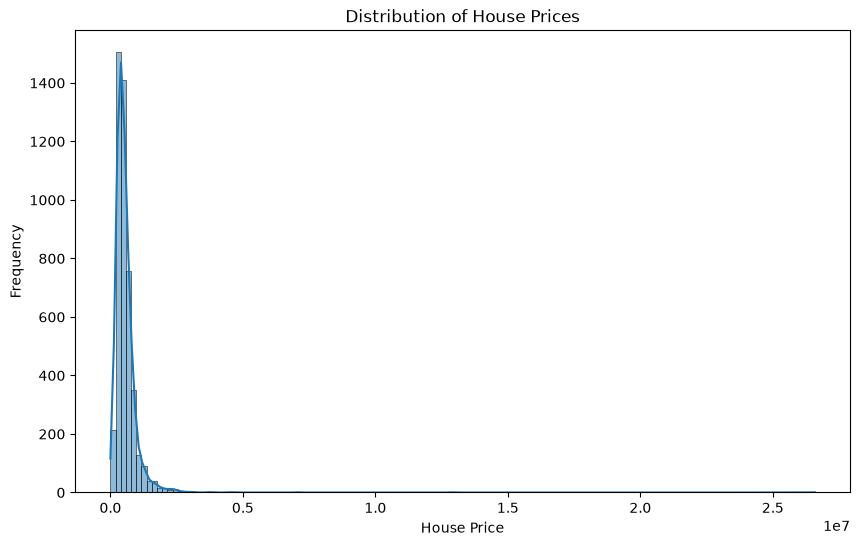

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price"],
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

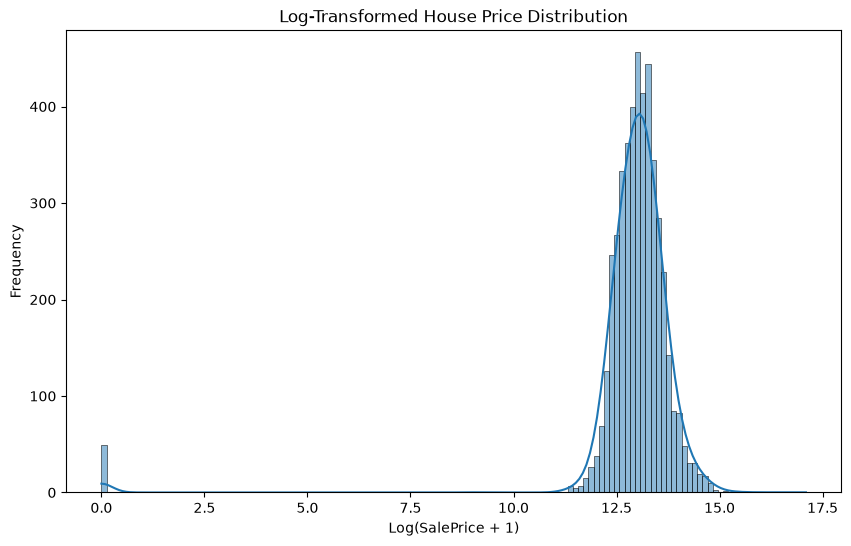

In [17]:
log_target = np.log1p(df["price"])

plt.figure(figsize=(10, 6))

sns.histplot(
    log_target,
    kde=True
)

plt.title("Log-Transformed House Price Distribution")
plt.xlabel("Log(SalePrice + 1)")
plt.ylabel("Frequency")

plt.show()

In [18]:
numeric_df = df.select_dtypes(
    include=np.number
)

print("Number of numerical columns:", numeric_df.shape[1])

Number of numerical columns: 13


In [19]:
correlation = numeric_df.corr()

target_correlation = correlation["price"].sort_values(
    ascending=False
)

print("Correlation with target:")
print(target_correlation)

Correlation with target:
price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64


In [20]:
top_correlations = (
    target_correlation
    .abs()
    .sort_values(ascending=False)
    .head(11)
)

print("Top correlated numerical features:")
print(top_correlations)

Top correlated numerical features:
price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
Name: price, dtype: float64


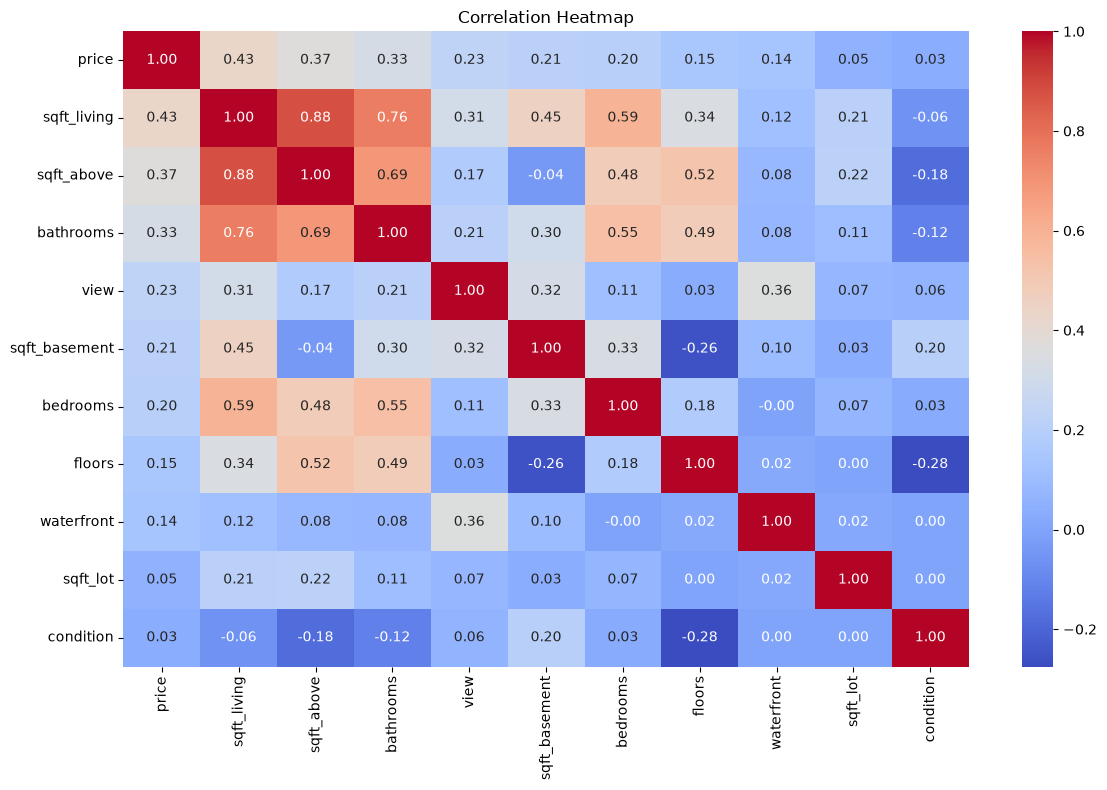

In [21]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df[top_correlations.index].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [22]:
if "GrLivArea" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="GrLivArea",
        y="price"
    )

    plt.title("Living Area vs House Price")
    plt.xlabel("Above Ground Living Area")
    plt.ylabel("House Price")

    plt.show()
else:
    print("GrLivArea column is not available in this dataset.")

GrLivArea column is not available in this dataset.


In [23]:
df_model = df.copy()

# ------------------------------------------------
# Total Bathroom
# ------------------------------------------------

if "FullBath" in df_model.columns and "HalfBath" in df_model.columns:

    df_model["TotalBath"] = (
        df_model["FullBath"] +
        0.5 * df_model["HalfBath"]
    )


# ------------------------------------------------
# Total Porch Area
# ------------------------------------------------

porch_columns = [
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "WoodDeckSF"
]

available_porch_columns = [
    col for col in porch_columns
    if col in df_model.columns
]

if available_porch_columns:

    df_model["TotalPorchSF"] = (
        df_model[available_porch_columns]
        .fillna(0)
        .sum(axis=1)
    )


# ------------------------------------------------
# Total House Area
# ------------------------------------------------

area_columns = [
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF"
]

available_area_columns = [
    col for col in area_columns
    if col in df_model.columns
]

if available_area_columns:

    df_model["TotalHouseArea"] = (
        df_model[available_area_columns]
        .fillna(0)
        .sum(axis=1)
    )


# ------------------------------------------------
# Total Rooms
# ------------------------------------------------

if "TotRmsAbvGrd" in df_model.columns:

    df_model["TotalRooms"] = (
        df_model["TotRmsAbvGrd"]
    )


print("Feature engineering completed.")
print("New dataset shape:", df_model.shape)

Feature engineering completed.
New dataset shape: (4600, 18)


In [24]:
X = df_model.drop(
    columns=["price"]
)

y = df_model["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4600, 17)
Target shape: (4600,)


In [25]:
id_columns = []

for column in X.columns:

    if column.lower() in ["id", "index"]:
        id_columns.append(column)

if id_columns:

    X = X.drop(
        columns=id_columns
    )

    print("Removed ID columns:", id_columns)

else:

    print("No ID columns found.")

print("Final feature shape:", X.shape)

No ID columns found.
Final feature shape: (4600, 17)


In [26]:
numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 12
Categorical features: 5


In [27]:
print("Numerical Features")
print("===================")

for feature in numeric_features:
    print(feature)

print("\nCategorical Features")
print("====================")

for feature in categorical_features:
    print(feature)

Numerical Features
bedrooms
bathrooms
sqft_living
sqft_lot
floors
waterfront
view
condition
sqft_above
sqft_basement
yr_built
yr_renovated

Categorical Features
date
street
city
statezip
country


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 3680
Testing samples : 920


In [29]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [30]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

print("Linear Regression model created.")

Linear Regression model created.


In [31]:
linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression training completed.")

Linear Regression training completed.


In [32]:
linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression predictions generated.")

Linear Regression predictions generated.


In [33]:
linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("==========================")
print("RMSE :", linear_rmse)
print("MAE  :", linear_mae)
print("R²   :", linear_r2)

Linear Regression Results
RMSE : 1076232.0296495142
MAE  : 308124.7451478717
R²   : -0.13573519472036866


In [34]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest model created.")

Random Forest model created.


In [35]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [36]:
rf_predictions = random_forest_model.predict(
    X_test
)

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [37]:
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("======================")
print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)
print("R²   :", rf_r2)

Random Forest Results
RMSE : 984569.4565434926
MAE  : 156195.96127947894
R²   : 0.049487185809092504


In [40]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
        
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "R2 Score": [
        linear_r2,
        rf_r2
        
    ]
})

results = results.sort_values(
    by="RMSE",
    ascending=True
)

results

,Model,RMSE,MAE,R2 Score
1,Random Forest,9.845695e+05,156195.961279,0.049487
0,Linear Regression,1.076232e+06,308124.745148,-0.135735


In [41]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [42]:
models = {

    "Linear Regression":
        linear_model,

    "Random Forest":
        random_forest_model

}

best_model = models[best_model_name]

print(
    "Selected model:",
    best_model_name
)

Selected model: Random Forest


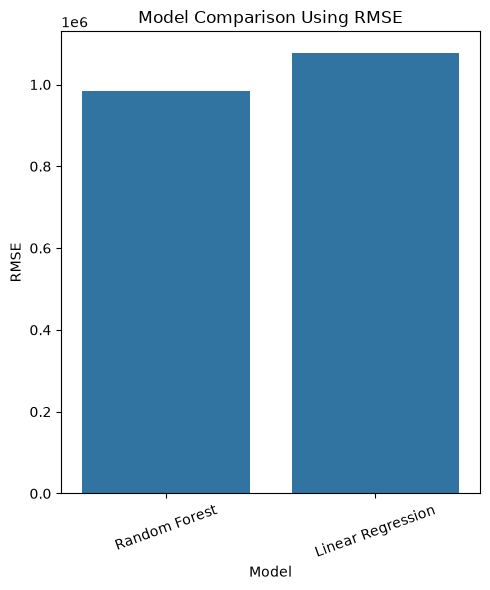

In [44]:
plt.figure(figsize=(5, 6))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison Using RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

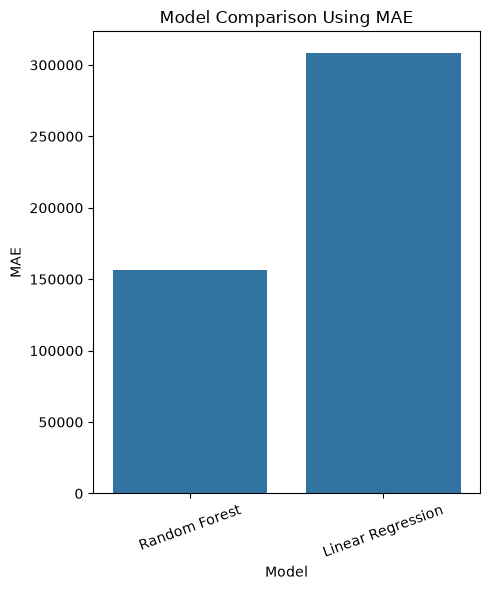

In [46]:
plt.figure(figsize=(5, 6))

sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)

plt.title("Model Comparison Using MAE")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [47]:
best_predictions = best_model.predict(
    X_test
)

residuals = (
    y_test -
    best_predictions
)

print("Residual analysis completed.")

Residual analysis completed.


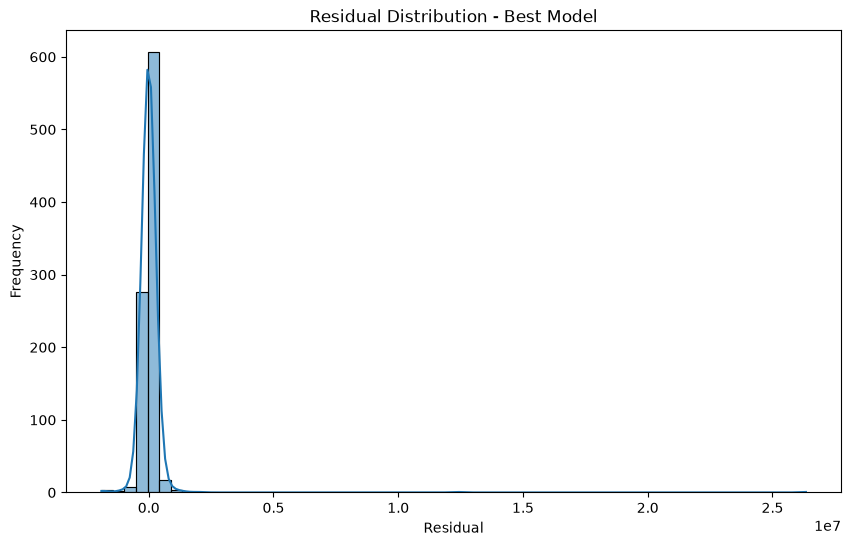

In [49]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution - Best Model"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

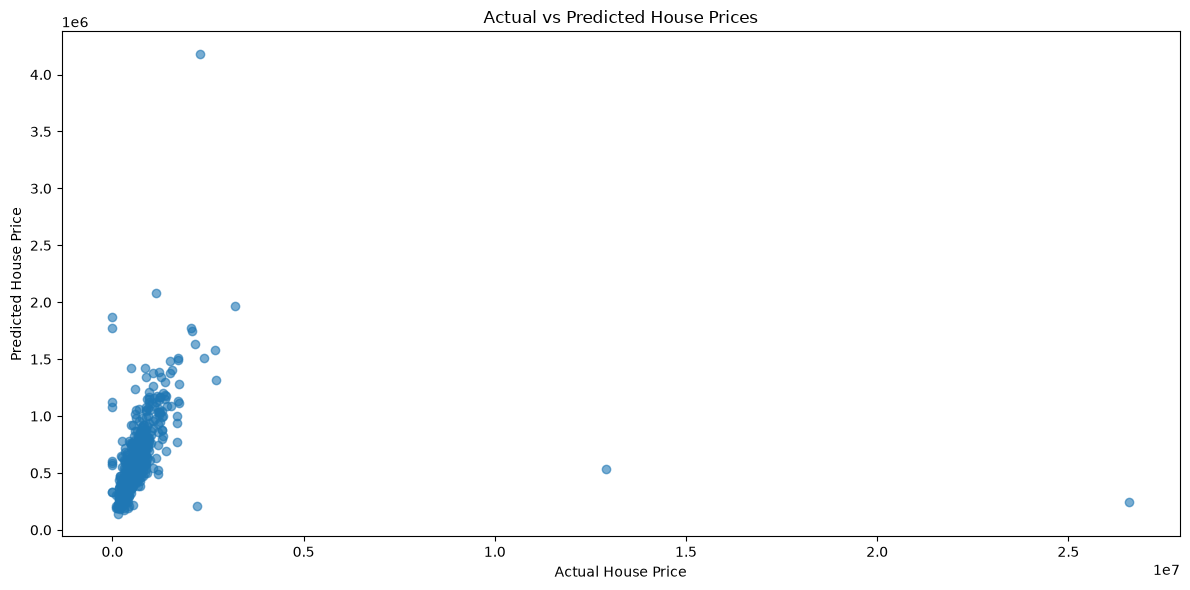

In [53]:
plt.figure(figsize=(12, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.tight_layout()
plt.show()

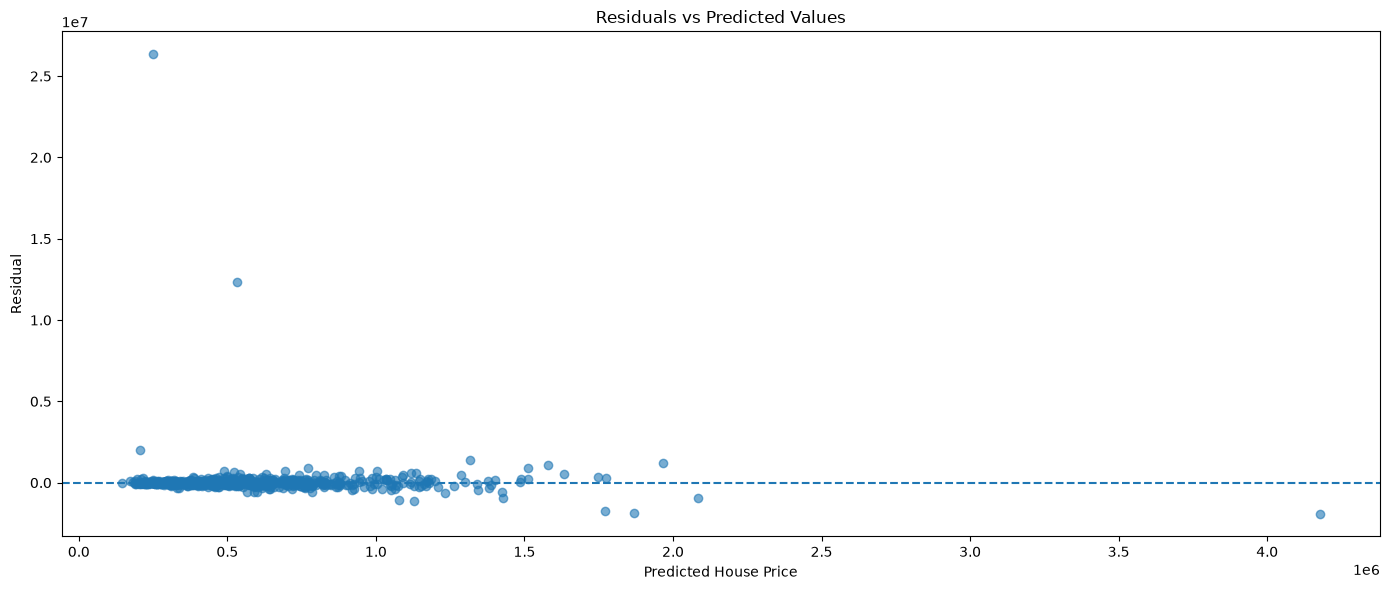

In [54]:
plt.figure(figsize=(14, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")

plt.title(
    "Residuals vs Predicted Values"
)

plt.tight_layout()
plt.show()

In [55]:
final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

final_mae = mean_absolute_error(
    y_test,
    best_predictions
)

final_r2 = r2_score(
    y_test,
    best_predictions
)

print("FINAL MODEL PERFORMANCE")
print("========================")
print("Best Model :", best_model_name)
print("RMSE       :", final_rmse)
print("MAE        :", final_mae)
print("R² Score   :", final_r2)

FINAL MODEL PERFORMANCE
Best Model : Random Forest
RMSE       : 984569.4565434926
MAE        : 156195.96127947894
R² Score   : 0.049487185809092504


In [56]:
model_filename = "house_price_model.pkl"

joblib.dump(
    best_model,
    model_filename
)

print(
    "Model saved successfully as:",
    model_filename
)

Model saved successfully as: house_price_model.pkl


In [57]:
loaded_model = joblib.load(
    "house_price_model.pkl"
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [58]:
sample_house = X_test.iloc[[0]]

predicted_price = loaded_model.predict(
    sample_house
)[0]

actual_price = y_test.iloc[0]

print("Actual House Price   :", actual_price)
print("Predicted House Price:", predicted_price)

Actual House Price   : 544000.0
Predicted House Price: 446681.7766666667


In [59]:
sample_houses = X_test.iloc[:5]

predictions = loaded_model.predict(
    sample_houses
)

prediction_results = pd.DataFrame({

    "Actual Price":
        y_test.iloc[:5].values,

    "Predicted Price":
        predictions

})

prediction_results

,Actual Price,Predicted Price
0,544000.0,4.466818e+05
1,0.0,3.298304e+05
2,1712500.0,1.136455e+06
3,365000.0,3.671009e+05
4,275000.0,2.481825e+05


In [60]:
prediction_results.to_csv(
    "house_price_predictions.csv",
    index=False
)

print(
    "Prediction results saved as house_price_predictions.csv"
)

Prediction results saved as house_price_predictions.csv


In [61]:
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
joblib
jupyter
"""

with open(
    "requirements.txt",
    "w"
) as file:

    file.write(requirements)

print("requirements.txt created successfully.")

requirements.txt created successfully.
